# Exploratory Data Analysis – EDA
Phân tích bộ dữ liệu điểm thi THPT từ 2022-2025.

## 1. Setup & Load Data

In [15]:
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
import viz
importlib.reload(viz)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [12]:
df = viz.load_data("../data/processed/final_data.csv")
print("Shape:", df.shape)

Shape: (4227695, 28)


In [13]:
df.head()

,nam,chuong_trinh,sbd,ma_tinh,ten_tinh,vung_mien,vung_3,ma_ngoai_ngu,toan,ngu_van,...,cong_nghe_cn,cong_nghe_nn,gd_ktpl,so_mon,ban,diem_khoi_a00,diem_khoi_a01,diem_khoi_b00,diem_khoi_c00,diem_khoi_d01
0,2022,2006,01000001,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,3.6,5.00,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,13.75,12.60
1,2022,2006,01000002,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,8.4,6.75,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,22.75,22.75
2,2022,2006,01000003,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,5.8,7.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,20.25,18.30
3,2022,2006,01000004,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,7.4,7.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,21.50,23.50
4,2022,2006,01000005,01,THÀNH PHỐ HÀ NỘI,Đồng bằng sông Hồng,Bắc,NA,7.2,8.50,...,NaN,NaN,NaN,6,KHXH,NaN,NaN,NaN,25.00,24.70


## 2. Tổng quan & dữ liệu thiếu
Quan sát tỷ lệ dữ liệu bị khuyết (nghĩa là không dự thi môn đó) và phân bố tổng số môn thi của các thí sinh.

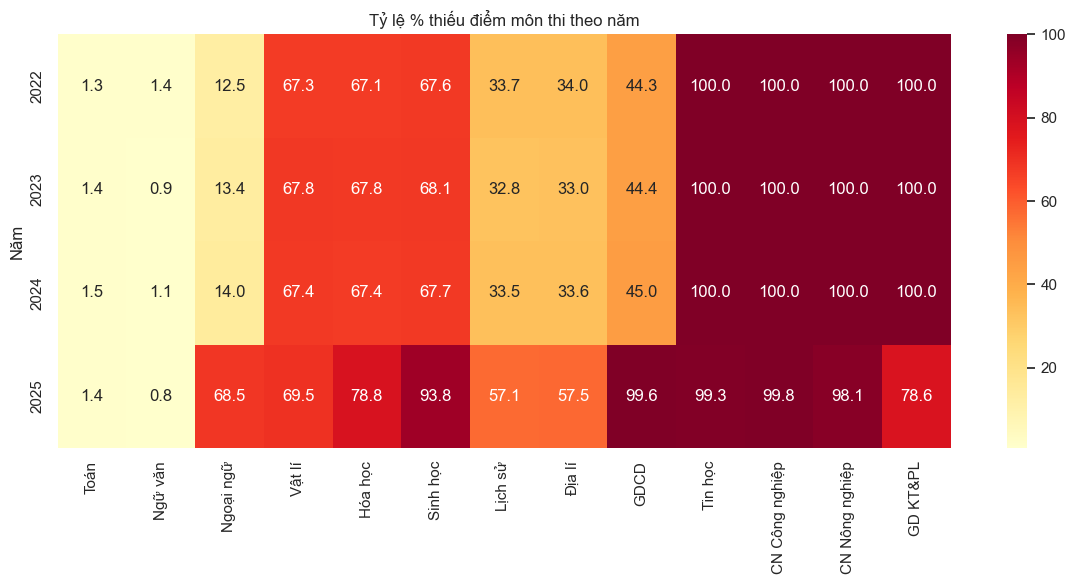

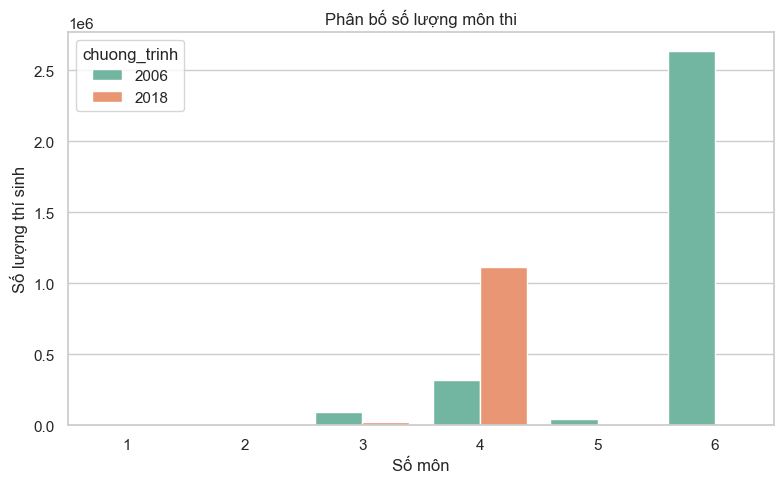

In [16]:
viz.plot_missing_heatmap(df)
plt.show()

viz.plot_so_mon_dist(df)
plt.show()

**Nhận xét:**
- Tỷ lệ khuyết điểm phản ánh rất rõ đặc thù khối thi: Môn bắt buộc như Toán, Ngữ Văn có tỷ lệ thiếu gần bằng 0, trong khi Lịch Sử, Địa Lí, Sinh Học... có phần lớn thí sinh không dự thi.
- Sự chuyển dịch sang Chương trình 2018 (CT2018) được phản ánh rõ trong phân bố số lượng môn thi: CT2006 tập trung ở mốc 6 môn, trong khi CT2018 số môn thi ít hơn do quy chế các môn lựa chọn mới.

### 2. Phổ điểm từng môn
Phân tích chi tiết phổ điểm, điểm liệt (<1), và điểm trung vị của từng môn học.

,Năm,Môn,Số lượng thí sinh,Mean,Median,Std,% < 1 (Điểm liệt),% >= 8 (Khá giỏi),% = 10 (Tuyệt đối)
0,2022,GDCD,554343,8.033266,8.25,1.067272,0.004510,61.850154,0.511597
1,2022,Hóa học,327367,6.703898,7.00,1.600393,0.006109,27.872693,0.048264
2,2022,Lịch sử,659662,6.343930,6.50,1.612879,0.003335,18.130649,0.269684
3,2022,Ngoại ngữ,870609,5.157686,4.80,1.949547,0.016885,12.090043,0.063748
4,2022,Ngữ văn,981407,6.507746,6.50,1.379602,0.016914,16.972367,0.000509
5,2022,Sinh học,322198,5.019109,4.75,1.448270,0.014587,4.590035,0.001552
6,2022,Toán,982726,6.466254,6.80,1.675435,0.005597,21.849122,0.003562
7,2022,Vật lí,325523,6.723779,7.00,1.441925,0.003379,22.746473,0.047308
8,2022,Địa lí,657421,6.677929,6.75,1.215013,0.005172,16.726877,0.024794
9,2023,GDCD,565452,8.285805,8.50,1.137638,0.004244,68.954748,2.598452


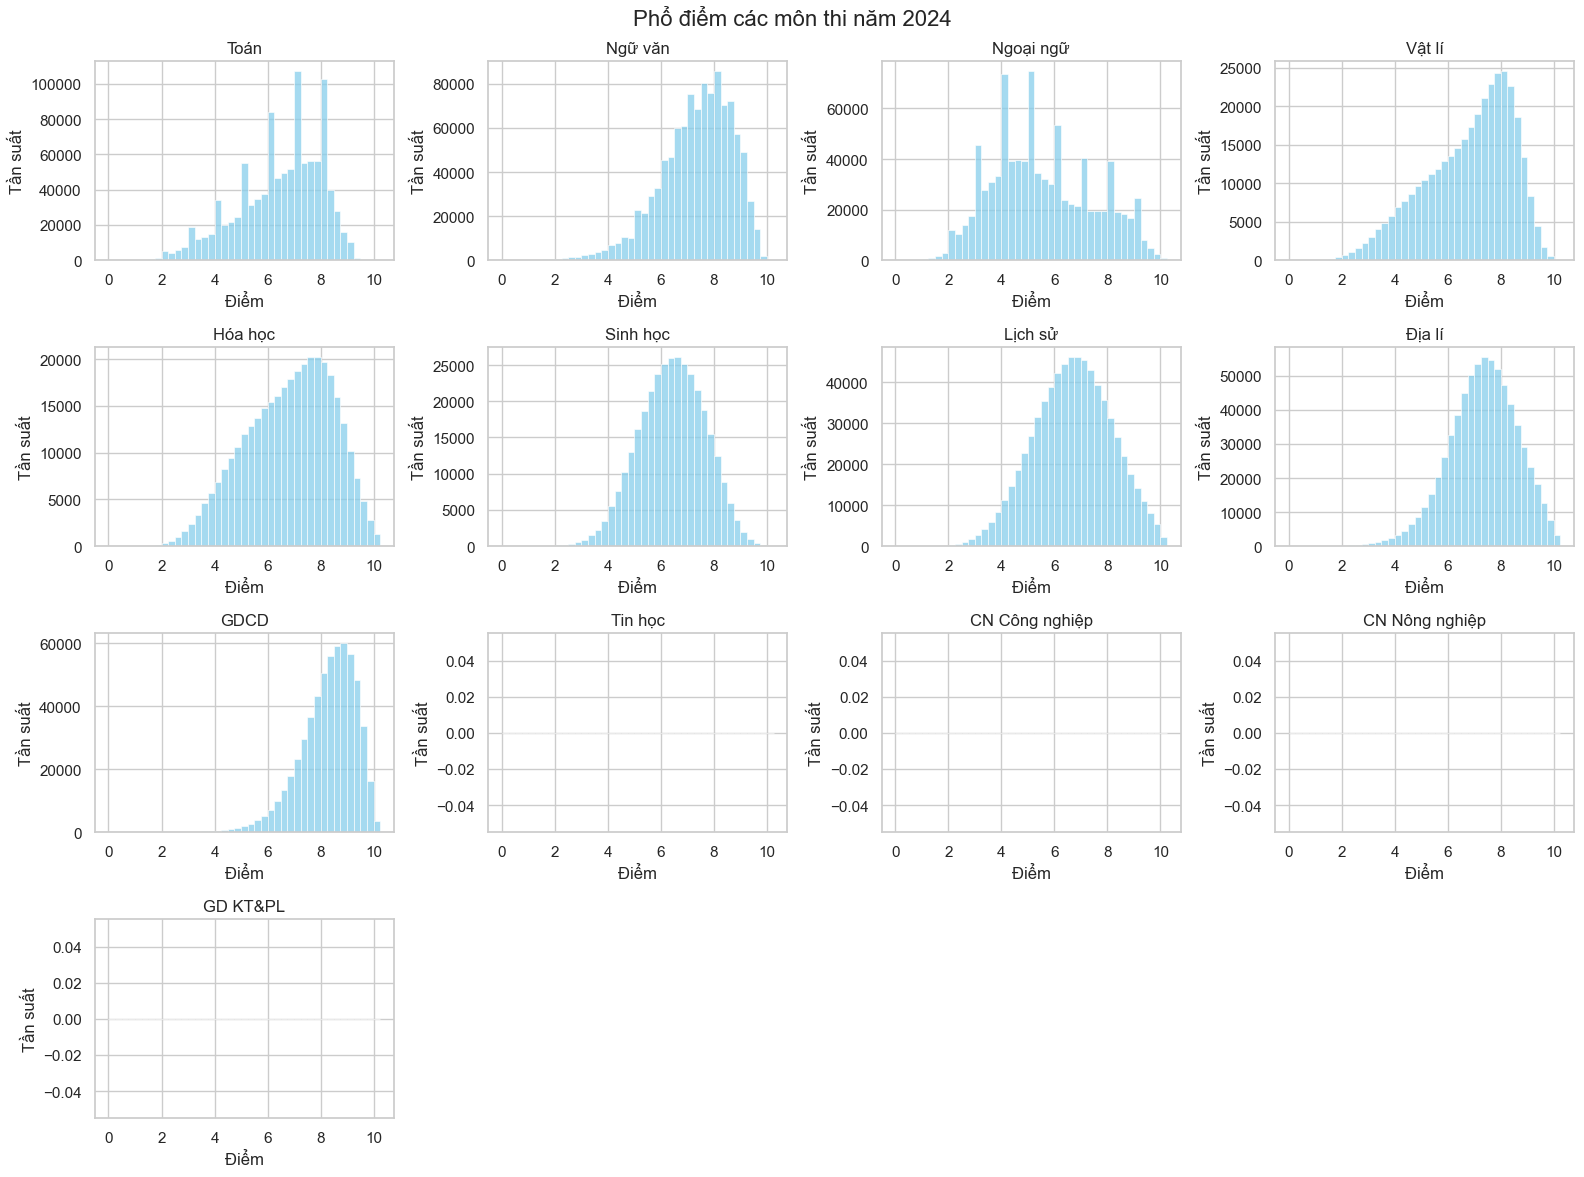

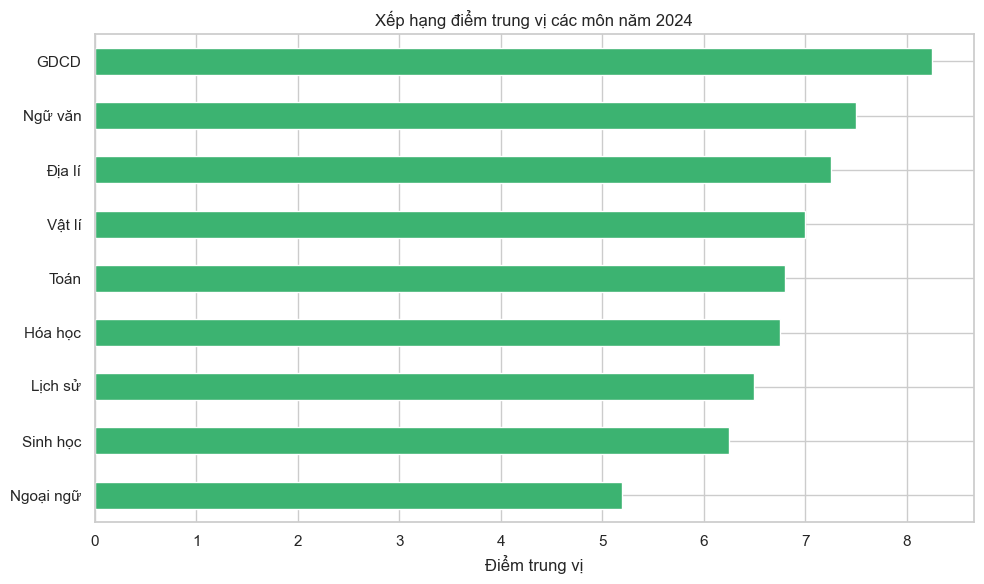

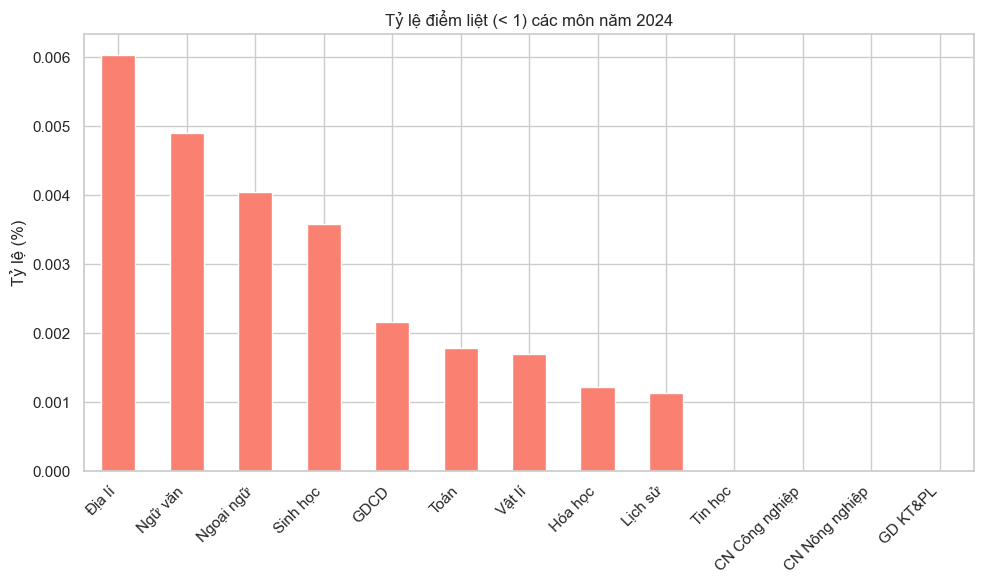

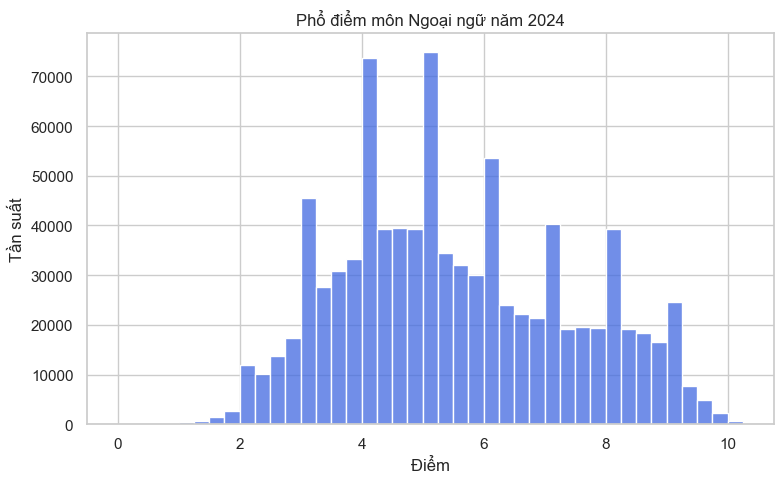

In [17]:
display(viz.summary_score_by_subject_year(df))

viz.plot_score_hist_grid(df, year=2024)
plt.show()

viz.plot_subject_median_rank(df, year=2024)
plt.show()

viz.plot_fail_rate_by_subject(df, year=2024)
plt.show()

viz.plot_score_hist_single(df, subject="ngoai_ngu", year=2024)
plt.show()

**Nhận xét:**
- **Phổ điểm:** Hầu hết các môn khoa học tự nhiên có phân phối lệch phải hoặc phân phối chuẩn hóa. Trong khi đó, GDCD luôn có phân phối lệch trái mạnh.
- **Điểm liệt:** Thường tập trung ở các môn như Ngoại ngữ hoặc Lịch sử.
- Ngoại ngữ có phổ điểm rất trải dài, thường có xu hướng đa đỉnh phản ánh mức độ phân hóa học sinh rất cao.

### §3. Xu hướng qua năm
Theo dõi sự biến động của điểm trung bình qua giai đoạn 2022-2024 và năm bản lề 2025.

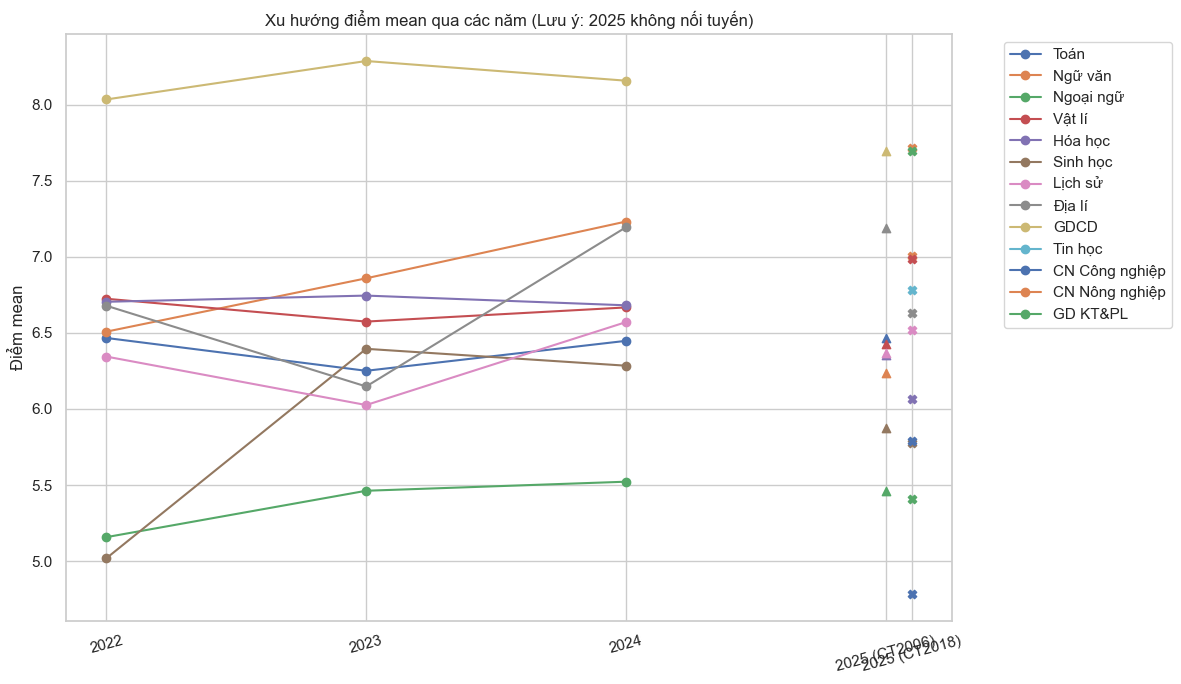

In [18]:
viz.plot_trend_2022_2024(df, stat="mean")
plt.show()

**Nhận xét:**
- **CẢNH BÁO:** Năm 2025 là năm đầu tiên áp dụng kỳ thi theo CT2018 (cùng với một bộ phận thi lại theo CT2006). Cấu trúc đề thi và định dạng thay đổi hoàn toàn nên **không thể cùng thước đo** với 2022-2024. Vì vậy điểm 2025 không được nối liền thành xu hướng liên tục.
- Trong giai đoạn 2022-2024, điểm trung bình các môn thi tương đối ổn định, chỉ biến động theo mức độ khó của đề thi hàng năm.

### §4. Địa lý (theo địa điểm dự thi)
So sánh sự khác biệt về kết quả thi giữa các tỉnh và các vùng kinh tế - xã hội (Đã giới hạn môn ngoại ngữ thành Tiếng Anh).

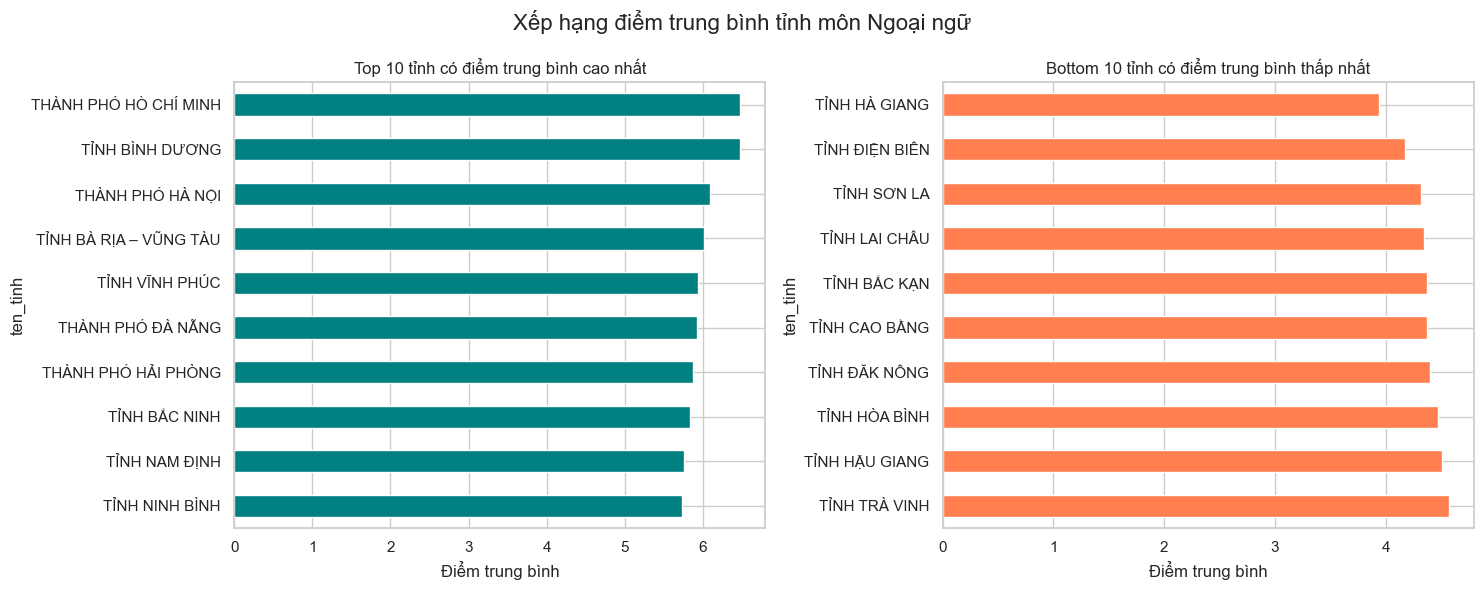

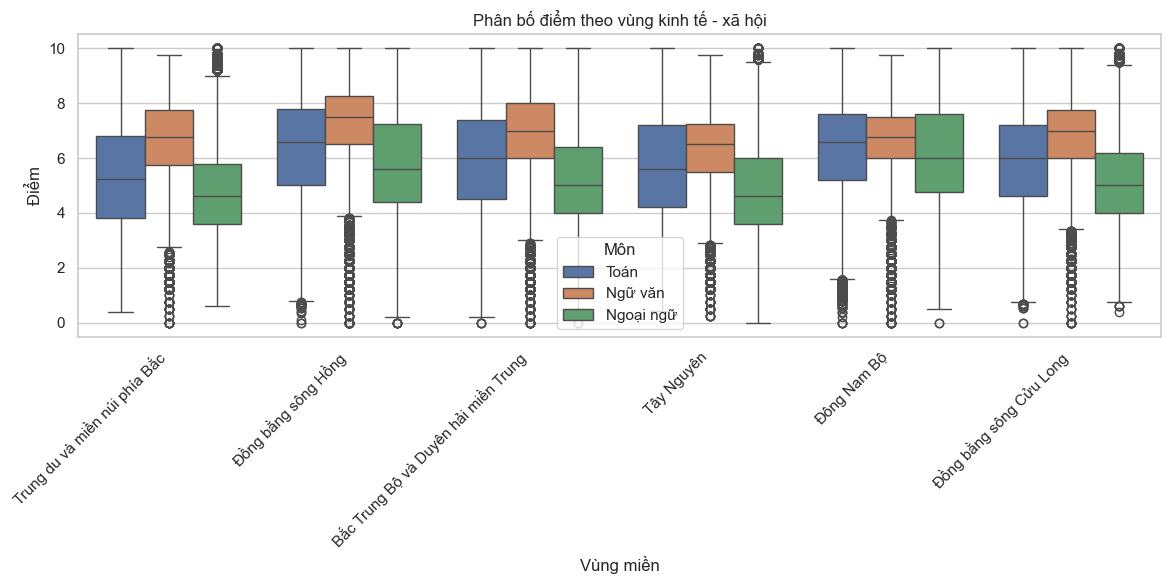

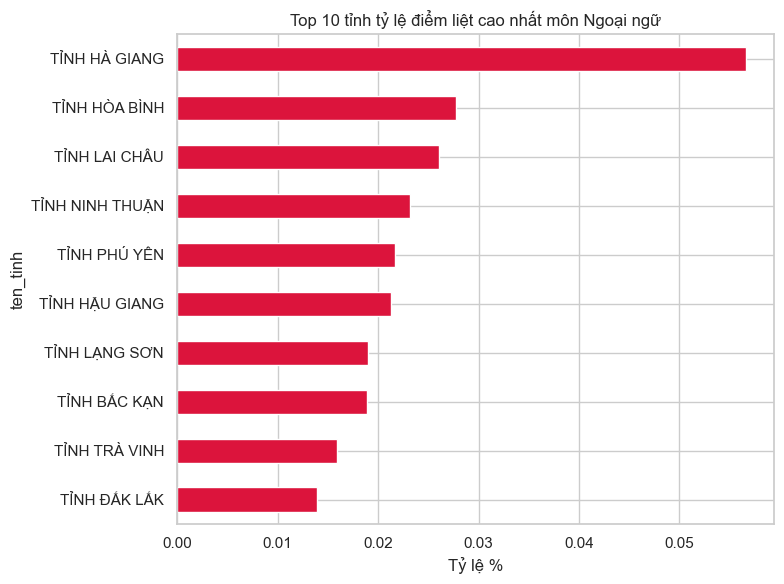

In [19]:
viz.plot_province_rank(df, subject="ngoai_ngu", top=10)
plt.show()

viz.plot_region_box(df, subjects=["toan", "ngu_van", "ngoai_ngu"])
plt.show()

viz.plot_fail_rate_by_province(df, subject="ngoai_ngu", top=10)
plt.show()

**Nhận xét:**
- Các tỉnh thuộc Đồng bằng sông Hồng và Đông Nam Bộ (như TP. HCM, Hà Nội, Bình Dương, Nam Định) thường giữ nhóm dẫn đầu ở môn Tiếng Anh và Toán.
- Miền núi phía Bắc và Tây Nguyên thường có điểm trung vị thấp hơn và tỷ lệ điểm liệt cao hơn ở môn Ngoại ngữ, cho thấy chênh lệch vùng miền rõ rệt trong giáo dục.
- *Lưu ý:* Mã tỉnh chỉ là nơi đăng ký Hội đồng thi.

### §5. Tương quan
Khám phá mức độ tương quan tuyến tính giữa các cặp môn học (pairwise corr).

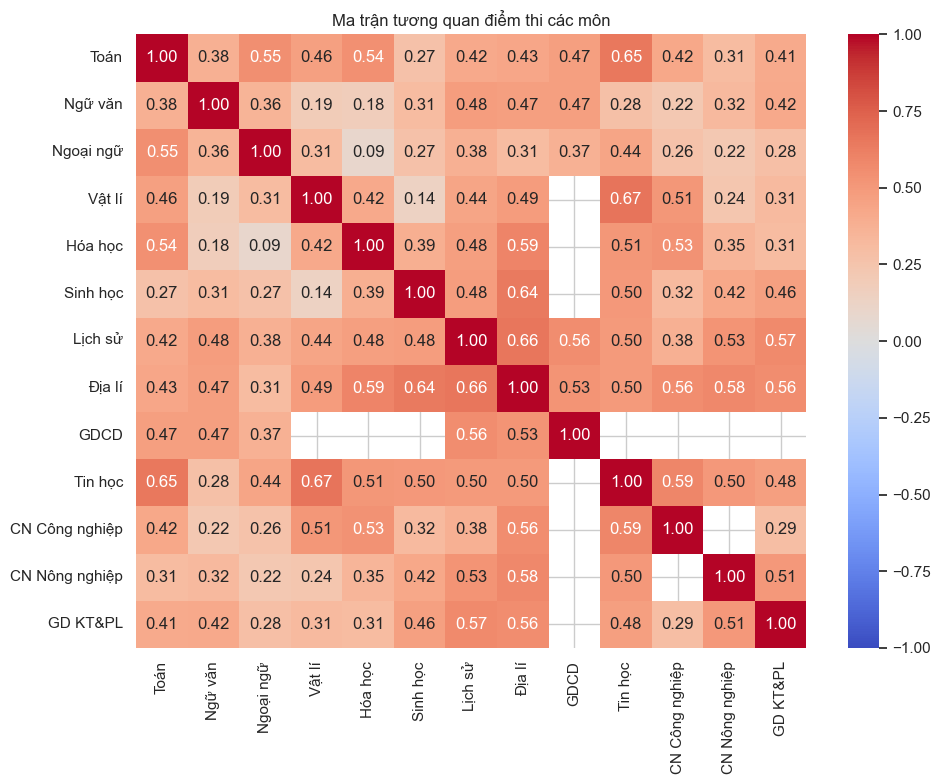

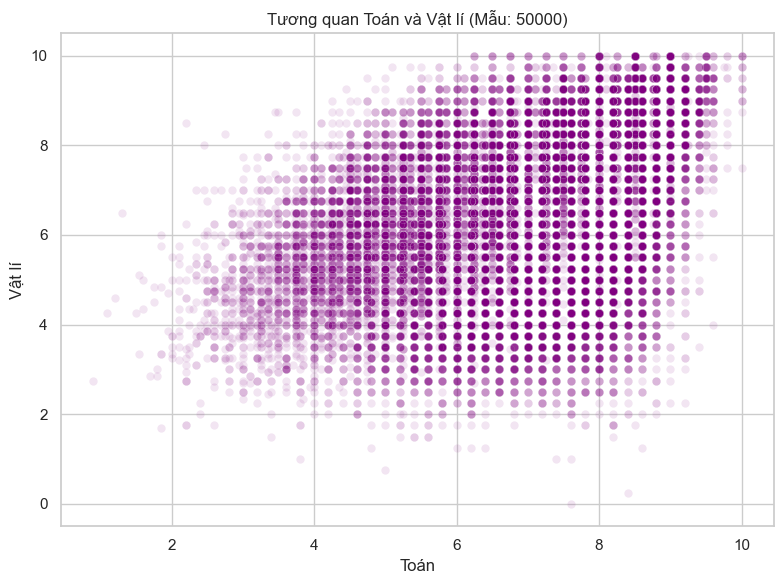

In [20]:
viz.plot_corr_heatmap(df)
plt.show()

viz.plot_subject_scatter(df, x="toan", y="vat_li", sample=50000)
plt.show()

**Nhận xét:**
- Các môn thuộc tổ hợp KHTN (Toán, Lý, Hóa) thường có hệ số tương quan dương khá chặt chẽ.
- Tương quan giữa nhóm KHTN và KHXH (Ví dụ: Vật Lí với Lịch Sử) thường ở mức rất thấp, phản ánh sự chuyên môn hóa của học sinh.

### §6. Lựa chọn tổ hợp theo vùng
Quan sát tỉ lệ lựa chọn ban (KHTN/KHXH) đối với CT2006 và tỉ lệ đăng ký các môn tự chọn mới đối với CT2018.

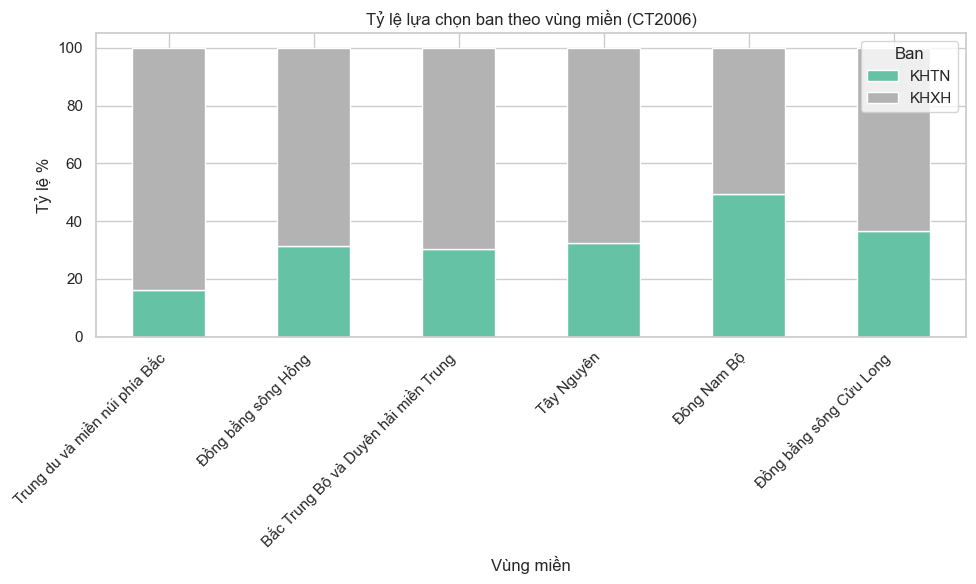

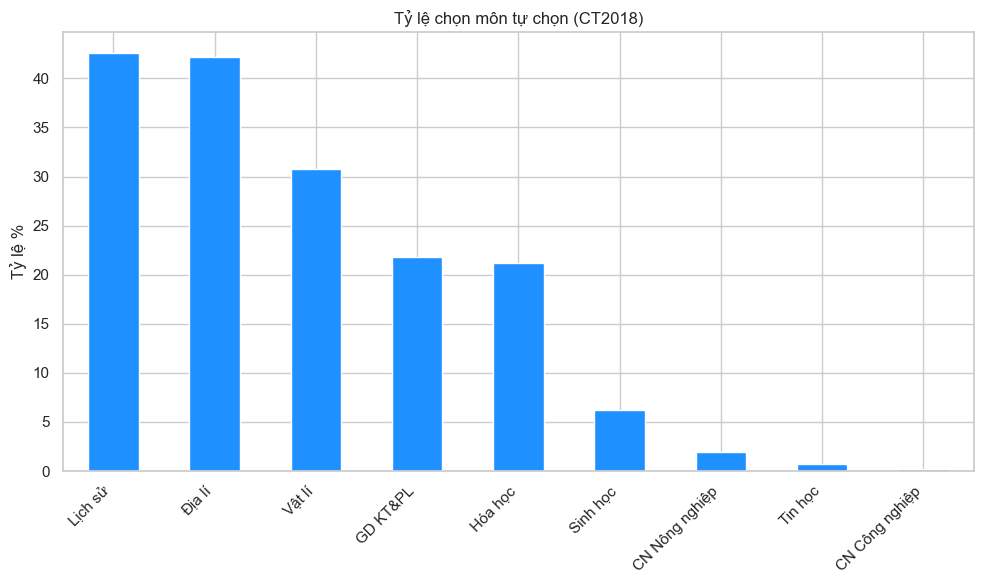

In [21]:
viz.plot_ban_by_region(df)
plt.show()

viz.plot_ct2018_subject_uptake(df)
plt.show()

**Nhận xét:**
- Khối KHXH áp đảo khối KHTN một cách rõ ràng trên toàn bộ các vùng miền trong hệ CT2006.
- Đối với CT2018, cơ chế chọn môn mới đã mở ra cơ hội cho các môn như Giáo dục KT&PL, Tin học, Địa lí vươn lên mạnh mẽ.